# Transformer Autoregressive Flow (TAF)

This notebook implements a Transformer-based Autoregressive Flow, which is the architectural counterpart to the MLP-based Masked Autoregressive Flow (MAF) implemented in `MaskedAutoregressiveFlows.ipynb`.

## Key Architectural Difference

In MAF, the autoregressive conditioner is a **MADE** network — a masked MLP where connectivity is constrained by binary masks to enforce causality. Each output `mu[i]` and `log_sigma[i]` can only depend on inputs `x[j]` with `j < i`.

Here, the MADE conditioner is replaced with a **Causal Transformer** — a stack of self-attention blocks where causality is enforced by an attention mask (each token can only attend to preceding tokens). This is the core design principle of TARFlow (Zhai et al., 2024):

> *"We replace the MLP based implementation with a much more powerful Transformer backbone [...] This seemingly simple change allows one to fully unlock the potentials of autoregressive flows."*

All other components — the affine transformation, the flow stacking, the permutations, the training objective — remain identical to the MAF implementation, making this a clean architectural ablation.

## Data Flow (per TAF block)
```
x: (B, D)  ──▶  unsqueeze  ──▶  (B, D, 1)   [D scalar tokens, each of dim 1]
             ──▶  proj_in   ──▶  (B, D, C)   [project each scalar to channel dim]
             ──▶  + pos_emb ──▶  (B, D, C)   [add learned positional embeddings]
             ──▶  CausalAttn x K ──▶ (B,D,C) [causal attention across D tokens]
             ──▶  proj_out  ──▶  (B, D, 2)   [(mu_raw, log_sigma_raw) per token]
             ──▶  shift -1  ──▶  (B, D, 2)   [shift so output_i uses only x_{<i}]
             ──▶  affine    ──▶  z = (x - mu) * exp(-log_sigma)
```

In [31]:
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn import datasets

## 1. Causal Self-Attention

The core building block. Each token in the sequence (B, N, C) attends only to preceding tokens via `is_causal=True` in `scaled_dot_product_attention`, which internally applies a causal mask. This is the Transformer equivalent of the binary weight masks in MADE.

The architecture follows `transformer_flow.py` from TARFlow (Zhai et al., 2024):
- Pre-norm (LayerNorm before attention)
- Fused QKV projection
- Residual connection around attention output
- Output projection back to channel dim

In [32]:
class CausalSelfAttention(nn.Module):
    """
    Multi-head causal self-attention.

    Causality is enforced via the `is_causal=True` flag in
    scaled_dot_product_attention, which applies a causal (lower-triangular)
    mask internally. Token i can attend to tokens 0, 1, ..., i only.

    Parameters
    ----------
    channels : int
        Model width. Must be divisible by head_dim.
    head_dim : int
        Dimension per attention head.
    """
    def __init__(self, channels: int, head_dim: int):
        super().__init__()
        assert channels % head_dim == 0, "channels must be divisible by head_dim"
        self.num_heads = channels // head_dim
        self.head_dim  = head_dim
        self.norm = nn.LayerNorm(channels)
        # Fused Q, K, V projection (3x channels output)
        self.qkv  = nn.Linear(channels, 3 * channels, bias=True)
        self.proj = nn.Linear(channels, channels, bias=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, N, C = x.shape
        x_norm = self.norm(x)
        # Project and split into Q, K, V heads: each (B, num_heads, N, head_dim)
        qkv = self.qkv(x_norm).reshape(B, N, 3, self.num_heads, self.head_dim)
        q, k, v = qkv.unbind(dim=2)           # each: (B, N, num_heads, head_dim)
        q = q.transpose(1, 2)                  # (B, num_heads, N, head_dim)
        k = k.transpose(1, 2)
        v = v.transpose(1, 2)
        # Causal attention: token i attends only to 0..i
        attn_out = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        attn_out = attn_out.transpose(1, 2).reshape(B, N, C)
        return self.proj(attn_out)

## 2. Transformer Block

A standard pre-norm Transformer block combining causal self-attention with a position-wise feed-forward MLP. Both sub-layers use residual connections.

Note: the MLP *inside* the Transformer block is not the same as the MADE/MLP conditioner being replaced. It is an internal component of each Transformer layer, operating independently on each token's channel representation.

In [33]:
class TransformerBlock(nn.Module):
    """
    Single Transformer layer: causal self-attention + position-wise MLP,
    both with pre-norm and residual connections.

    Parameters
    ----------
    channels : int
        Model width.
    head_dim : int
        Per-head dimension for attention.
    mlp_expansion : int
        Hidden width multiplier for the feed-forward MLP (default 4,
        following TARFlow and standard Transformer practice).
    """
    def __init__(self, channels: int, head_dim: int, mlp_expansion: int = 4):
        super().__init__()
        self.attn  = CausalSelfAttention(channels, head_dim)
        self.norm2 = nn.LayerNorm(channels)
        self.mlp   = nn.Sequential(
            nn.Linear(channels, channels * mlp_expansion),
            nn.GELU(),
            nn.Linear(channels * mlp_expansion, channels),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.attn(x)           # attention sub-layer with residual
        x = x + self.mlp(self.norm2(x))  # MLP sub-layer with residual
        return x

## 3. Causal Transformer Conditioner

This is the direct replacement for `MADE`. It produces the shift (μ) and log-scale (log σ) parameters for the affine transformation, conditioned causally on preceding dimensions.

### Causality mechanism

In MADE, causality is enforced by masking weights to zero. Here, causality is enforced through two complementary mechanisms:

1. **Causal attention mask**: token `i` can only attend to tokens `0, 1, ..., i` (enforced by `is_causal=True`).
2. **Output shift by 1**: after the Transformer, the output at position `i` has seen tokens `0..i` (inclusive of `x_i` itself). We shift the output sequence by one position so that the parameters for dimension `i` are derived from the output at position `i-1`, which has only seen `x_0, ..., x_{i-1}`. The first position gets zeros (no context).

This is equivalent to TARFlow's approach (Zhai et al., 2024, Eq. 3) where `μ_i^t(z̃_{<i})` conditions only on preceding tokens.

### Output initialisation

`proj_out` weights and biases are initialised to zero, following TARFlow:
> *"The output layer of each flow block [...] is initialised as zeros."* (Zhai et al., 2024)

This ensures that at initialisation the flow is an identity transformation (μ=0, log_σ=0), which stabilises early training.

In [34]:
class CausalTransformerConditioner(nn.Module):
    """
    Causal Transformer conditioner — drop-in replacement for MADE.

    Treats each of the D input scalars as a separate token of dimension 1,
    projects to a hidden channel dimension, applies K layers of causal
    self-attention, then projects back to (mu, log_sigma) per token.
    A one-position output shift ensures mu[i] depends only on x_{<i}.

    Parameters
    ----------
    D           : int  — input/output dimensionality
    channels    : int  — Transformer hidden width
    num_layers  : int  — number of Transformer blocks (K in TARFlow notation)
    head_dim    : int  — per-head attention dimension
    mlp_expansion: int — MLP expansion factor inside each Transformer block
    cond_size   : int or None — size of optional conditioning vector y
    """
    def __init__(
        self,
        D: int,
        channels: int,
        num_layers: int,
        head_dim: int = 16,
        mlp_expansion: int = 4,
        cond_size: int = None,
    ):
        super().__init__()
        self.D = D
        # Project each scalar token (dim=1) to channel width
        self.proj_in   = nn.Linear(1, channels)
        # Learned positional embeddings: one per sequence position (dimension)
        self.pos_embed = nn.Parameter(torch.randn(D, channels) * 0.02)
        # Optional conditioning: projects y to channel width, broadcast over D
        self.cond_proj = nn.Linear(cond_size, channels, bias=False) if cond_size else None
        # Stack of causal Transformer blocks
        self.blocks = nn.ModuleList([
            TransformerBlock(channels, head_dim, mlp_expansion)
            for _ in range(num_layers)
        ])
        # Output head: projects each token's representation to (mu, log_sigma)
        self.proj_out = nn.Linear(channels, 2)
        # Zero-init: identity flow at initialisation (Zhai et al., 2024)
        nn.init.zeros_(self.proj_out.weight)
        nn.init.zeros_(self.proj_out.bias)

    def forward(self, x: torch.Tensor, y: torch.Tensor = None):
        """
        Parameters
        ----------
        x : (B, D)  — input sequence
        y : (B, cond_size) or None — optional conditioning vector

        Returns
        -------
        mu        : (B, D)
        log_sigma : (B, D)
        """
        B, D = x.shape
        # Step 1: treat each scalar as a token of dim 1, project to channels
        tokens = self.proj_in(x.unsqueeze(-1))         # (B, D, C)
        # Step 2: add positional embeddings
        tokens = tokens + self.pos_embed.unsqueeze(0)  # (B, D, C)
        # Step 3: add conditioning (broadcast across sequence dimension)
        if self.cond_proj is not None and y is not None:
            tokens = tokens + self.cond_proj(y).unsqueeze(1)  # (B, 1, C) -> broadcast
        # Step 4: causal Transformer layers
        for blk in self.blocks:
            tokens = blk(tokens)                       # (B, D, C)
        # Step 5: project to (mu, log_sigma) per token
        out = self.proj_out(tokens)                    # (B, D, 2)
        # Step 6: causal shift — output at position i has attended to x_0..x_i
        #   We want params for dim i to depend only on x_{<i}, so shift by 1:
        #   params[i] <- output[i-1], and params[0] <- zeros (no context)
        out_shifted = torch.cat([
            torch.zeros(B, 1, 2, device=x.device, dtype=x.dtype),
            out[:, :-1, :]
        ], dim=1)                                       # (B, D, 2)
        mu        = out_shifted[..., 0]                 # (B, D)
        log_sigma = out_shifted[..., 1]                 # (B, D)
        return mu, log_sigma

## 4. TAF Block

Identical in structure to `MAFBlock`, with `CausalTransformerConditioner` in place of `MADE`.

- **Forward** (encoding, parallel): `z = (x - μ(x)) ⊙ exp(−log σ(x))`
- **Reverse** (sampling, sequential): `x_i = z_i ⊙ exp(log σ_i(x_{<i})) + μ_i(x_{<i})`

The log-determinant is `−∑ log σ_i` (sum of diagonal of the lower-triangular Jacobian).

In [35]:
class TAFBlock(nn.Module):
    """
    Single Transformer Autoregressive Flow block.

    Implements the affine autoregressive transformation:
        forward:  z = (x - mu) * exp(-log_sigma)   [parallel, O(1)]
        reverse:  x_i = z_i * exp(log_sigma_i) + mu_i  [sequential, O(D)]

    The conditioner is a CausalTransformerConditioner instead of MADE.

    Parameters
    ----------
    D           : int  — data dimensionality
    channels    : int  — Transformer hidden width
    num_layers  : int  — Transformer depth (K)
    head_dim    : int  — per-head attention dimension
    cond_size   : int or None
    clamp       : float — log_sigma clamp for numerical stability
    """
    def __init__(
        self,
        D: int,
        channels: int,
        num_layers: int,
        head_dim: int = 16,
        cond_size: int = None,
        clamp: float = 5.0,
    ):
        super().__init__()
        self.D     = D
        self.clamp = clamp
        self.net   = CausalTransformerConditioner(
            D, channels, num_layers, head_dim, cond_size=cond_size
        )

    def forward(self, x: torch.Tensor, y: torch.Tensor = None):
        """Encode x -> z (parallel). Returns (z, log_det)."""
        mu, log_sigma = self.net(x, y)
        log_sigma = torch.clamp(log_sigma, -self.clamp, self.clamp)
        z      = (x - mu) * torch.exp(-log_sigma)
        logdet = -log_sigma.sum(dim=-1)             # (B,)
        return z, logdet

    @torch.no_grad()
    def reverse(self, z: torch.Tensor, y: torch.Tensor = None) -> torch.Tensor:
        """Decode z -> x (sequential, O(D) forward passes)."""
        x = torch.zeros_like(z)
        for i in range(self.D):
            mu, log_sigma = self.net(x, y)
            log_sigma = torch.clamp(log_sigma, -self.clamp, self.clamp)
            x[:, i]   = z[:, i] * torch.exp(log_sigma[:, i]) + mu[:, i]
        return x

## 5. Permute Layer

Identical to the MAF implementation — a volume-preserving permutation with zero log-determinant, used to alternate the autoregression direction between flow blocks.

In [36]:
class Permute(nn.Module):
    """
    Fixed permutation layer. Volume-preserving (log-det = 0).
    Inverse permutation is pre-computed at construction.
    """
    def __init__(self, perm: list):
        super().__init__()
        self.register_buffer("perm",     torch.tensor(perm, dtype=torch.long))
        inv = torch.empty_like(self.perm)
        inv[self.perm] = torch.arange(len(perm))
        self.register_buffer("inv_perm", inv)

    def forward(self, x: torch.Tensor, y=None):
        return x[:, self.perm], torch.zeros(x.size(0), device=x.device)

    @torch.no_grad()
    def reverse(self, z: torch.Tensor, y=None) -> torch.Tensor:
        return z[:, self.inv_perm]

## 6. TAF — Full Model

Stacks T `TAFBlock` layers with interleaved `Permute` layers. Structurally identical to `MAF`, with `TAFBlock` replacing `MAFBlock`.

Following TARFlow (Zhai et al., 2024), the permutation alternates the autoregression direction between successive blocks (reverse ordering on odd blocks), which is essential for universality: with T ≥ 3 alternating blocks, the model is a universal approximator of any continuous density in L¹(ℝᴰ) (Gu et al., 2025, Proposition 1).

In [37]:
class TAF(nn.Module):
    """
    Transformer Autoregressive Flow.

    Stacks T TAFBlocks with interleaved Permute layers.
    Identical structure to MAF but with a Transformer conditioner.

    Parameters
    ----------
    input_size     : int  — data dimensionality D
    channels       : int  — Transformer hidden width
    num_layers     : int  — Transformer depth per flow block (K)
    head_dim       : int  — per-head attention dimension
    blocks         : int  — number of flow blocks (T, should be ≥ 3)
    condition_size : int or None
    """
    def __init__(
        self,
        input_size: int,
        channels: int       = 32,
        num_layers: int     = 1,
        head_dim: int       = 16,
        blocks: int         = 4,
        condition_size: int = None,
    ):
        super().__init__()
        self.input_size     = input_size
        self.condition_size = condition_size

        self.blocks = nn.ModuleList()
        for i in range(blocks):
            self.blocks.append(
                TAFBlock(
                    D=input_size,
                    channels=channels,
                    num_layers=num_layers,
                    head_dim=head_dim,
                    cond_size=condition_size,
                )
            )
            # Skip Permute after the final block (unlike MAF — avoids redundant op)
            if i < blocks - 1:
                self.blocks.append(Permute(list(reversed(range(input_size)))))

    def forward(self, x: torch.Tensor, y: torch.Tensor = None):
        """Encode: x -> z. Returns (z, log_det_jacobian)."""
        log_det = torch.zeros(x.size(0), device=x.device)
        h = x
        for layer in self.blocks:
            h, ld = layer(h, y)
            log_det = log_det + ld
        return h, log_det

    def reverse(self, z: torch.Tensor, y: torch.Tensor = None) -> torch.Tensor:
        """Decode: z -> x."""
        h = z
        for layer in reversed(self.blocks):
            h = layer.reverse(h, y)
        return h

    def sample(self, n_samples: int, y: torch.Tensor = None) -> torch.Tensor:
        """Draw samples by inverting a standard Gaussian."""
        device = y.device if y is not None else next(self.parameters()).device
        z = torch.randn(n_samples, self.input_size, device=device)
        return self.reverse(z, y)

## 7. Correctness Verification

Before training, we verify three invariants that must hold for any correct autoregressive flow:

1. **Causality**: `mu[i]` and `log_sigma[i]` must depend only on `x[j]` with `j < i`
2. **Round-trip**: `reverse(forward(x)) ≈ x` to numerical precision
3. **Log-determinant sign**: encodes volume change correctly (logdet < 0 means contraction)

In [38]:
torch.manual_seed(0)
D = 5

# ── Test 1: Causality ─────────────────────────────────────────────────────────
print("=" * 55)
print("TEST 1: Causal dependency of mu[i] on x (D=5)")
print("=" * 55)
conditioner = CausalTransformerConditioner(D=D, channels=16, num_layers=1, head_dim=8)
# Break zero-init for gradient tracing
with torch.no_grad():
    conditioner.proj_out.weight.data = torch.randn_like(conditioner.proj_out.weight) * 0.1
    conditioner.proj_out.bias.data   = torch.randn_like(conditioner.proj_out.bias)   * 0.1

x_test = torch.randn(1, D, requires_grad=True)
mu, log_sigma = conditioner(x_test)
for i in range(D):
    if x_test.grad is not None: x_test.grad.zero_()
    mu[0, i].backward(retain_graph=True)
    deps   = (x_test.grad[0].abs() > 1e-8).nonzero(as_tuple=True)[0].tolist()
    causal = all(d < i for d in deps)
    status = "✓" if causal else "✗ VIOLATION"
    print(f"  {status}  mu[{i}] depends on x{deps}   (expected: x{list(range(i))})")

print()

# ── Test 2: TAFBlock round-trip ───────────────────────────────────────────────
print("=" * 55)
print("TEST 2: TAFBlock forward → reverse round-trip")
print("=" * 55)
block   = TAFBlock(D=D, channels=16, num_layers=1, head_dim=8)
x_orig  = torch.randn(10, D)
z, logdet = block(x_orig)
x_rec   = block.reverse(z)
err     = (x_orig - x_rec).abs().max().item()
status  = "✓" if err < 1e-5 else "✗"
print(f"  {status}  Max |x - reverse(forward(x))| = {err:.2e}   (want < 1e-5)")

print()

# ── Test 3: Full TAF round-trip ───────────────────────────────────────────────
print("=" * 55)
print("TEST 3: Full TAF (4 blocks) round-trip (D=2)")
print("=" * 55)
taf    = TAF(input_size=2, channels=16, num_layers=1, head_dim=8, blocks=4)
x_orig = torch.randn(20, 2)
z, _   = taf(x_orig)
x_rec  = taf.reverse(z)
err    = (x_orig - x_rec).abs().max().item()
status = "✓" if err < 1e-5 else "✗"
print(f"  {status}  Max |x - reverse(forward(x))| = {err:.2e}   (want < 1e-5)")

print()

# ── Summary: parameter count ──────────────────────────────────────────────────
print("=" * 55)
print("TAF model parameter count (input_size=2, channels=16, num_layers=1, blocks=4)")
print("=" * 55)
n_params = sum(p.numel() for p in taf.parameters())
print(f"  Total parameters: {n_params:,}")

TEST 1: Causal dependency of mu[i] on x (D=5)
  ✓  mu[0] depends on x[]   (expected: x[])
  ✓  mu[1] depends on x[0]   (expected: x[0])
  ✓  mu[2] depends on x[0, 1]   (expected: x[0, 1])
  ✓  mu[3] depends on x[0, 1, 2]   (expected: x[0, 1, 2])
  ✓  mu[4] depends on x[0, 1, 2, 3]   (expected: x[0, 1, 2, 3])

TEST 2: TAFBlock forward → reverse round-trip
  ✓  Max |x - reverse(forward(x))| = 0.00e+00   (want < 1e-5)

TEST 3: Full TAF (4 blocks) round-trip (D=2)
  ✓  Max |x - reverse(forward(x))| = 0.00e+00   (want < 1e-5)

TAF model parameter count (input_size=2, channels=16, num_layers=1, blocks=4)
  Total parameters: 13,512


## 8. Dataset Utilities

Identical to the MAF notebook — fixed random seeds are added for reproducibility of train/test splits across model comparisons.

In [39]:
def get_moons_unconditional(n_samples: int = 1000, noise: float = 0.1, seed: int = 42):
    X, _ = datasets.make_moons(n_samples=n_samples, noise=noise, random_state=seed)
    X    = torch.tensor(X, dtype=torch.float32)
    dataset    = torch.utils.data.TensorDataset(X)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)
    return dataloader, X

def get_moons_conditional(n_samples: int = 1000, noise: float = 0.1, seed: int = 42):
    X, y = datasets.make_moons(n_samples=n_samples, noise=noise, random_state=seed)
    X    = torch.tensor(X, dtype=torch.float32)
    y    = F.one_hot(torch.tensor(y), num_classes=2).float()
    dataset    = torch.utils.data.TensorDataset(X, y)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)
    return dataloader, X, y

## 9. Training Loop

Identical to the MAF notebook. The NLL loss uses `math.log(2π)` as a Python float constant rather than `torch.tensor(2*torch.pi)`, avoiding unnecessary graph nodes in the computation graph.

In [40]:
def train_taf(model, dataloader, epochs: int = 200, lr: float = 1e-3):
    """
    Train a TAF (or MAF) model via maximum likelihood.

    Loss = E[-log p(x)] = E[0.5*D*log(2π) + 0.5*||z||² - log|det J|]
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    model.train()
    log_2pi   = math.log(2 * math.pi)   # constant: avoid graph node each step
    losses    = []

    for epoch in range(epochs):
        epoch_loss = 0.0
        for batch in dataloader:
            x = batch[0]
            D = x.shape[1]
            y = batch[1] if model.condition_size is not None else None

            z, log_det = model(x, y)

            # Gaussian NLL: 0.5 * [D*log(2π) + ||z||² ] - log|det J|
            nll  = 0.5 * D * log_2pi + 0.5 * z.pow(2).sum(dim=1) - log_det
            loss = nll.mean()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        losses.append(epoch_loss)

    return model, losses

def plot_lc(losses, title="Training Loss"):
    plt.figure(figsize=(7, 3))
    plt.plot(losses)
    plt.xlabel("Epoch")
    plt.ylabel("Total Training Loss")
    plt.title(title)
    plt.tight_layout()
    plt.show()

## 10. Unconditional Training

TAF unconditional — parameters: 51,592


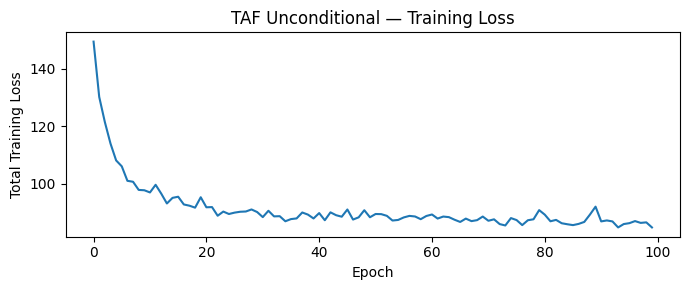

In [42]:
torch.manual_seed(0)

uncond_loader, X_uncond = get_moons_unconditional(n_samples=5000, seed=0)

taf = TAF(
    input_size=2,
    channels=32,      # Transformer hidden width
    num_layers=1,     # Transformer layers per flow block (K)
    head_dim=16,      # per-head attention dimension
    blocks=4,         # number of flow blocks (T ≥ 3 for universality)
)

print(f"TAF unconditional — parameters: {sum(p.numel() for p in taf.parameters()):,}")

taf, taf_losses = train_taf(taf, uncond_loader, epochs=100, lr=1e-3)
plot_lc(taf_losses, "TAF Unconditional — Training Loss")

taf.eval()
samples_uncond = taf.sample(2000).detach().numpy()

## 11. Conditional Training

TAF conditional — parameters: 51,848


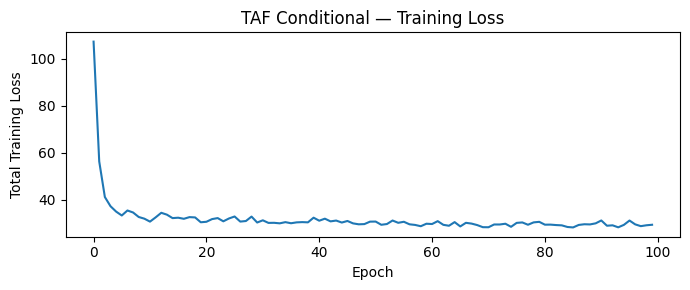

In [43]:
torch.manual_seed(0)

cond_loader, X_cond, y_cond = get_moons_conditional(n_samples=5000, seed=0)

ctaf = TAF(
    input_size=2,
    channels=32,
    num_layers=1,
    head_dim=16,
    blocks=4,
    condition_size=2,   # one-hot class label
)

print(f"TAF conditional — parameters: {sum(p.numel() for p in ctaf.parameters()):,}")

ctaf, ctaf_losses = train_taf(ctaf, cond_loader, epochs=100, lr=1e-3)
plot_lc(ctaf_losses, "TAF Conditional — Training Loss")

## 12. Conditional Sampling (per class)

In [44]:
ctaf.eval()
n = 2000

y0 = torch.zeros(n, 2); y0[:, 0] = 1.0   # class 0
y1 = torch.zeros(n, 2); y1[:, 1] = 1.0   # class 1

samples0 = ctaf.sample(n, y=y0).detach().cpu().numpy()
samples1 = ctaf.sample(n, y=y1).detach().cpu().numpy()

## 13. Sample Visualisation

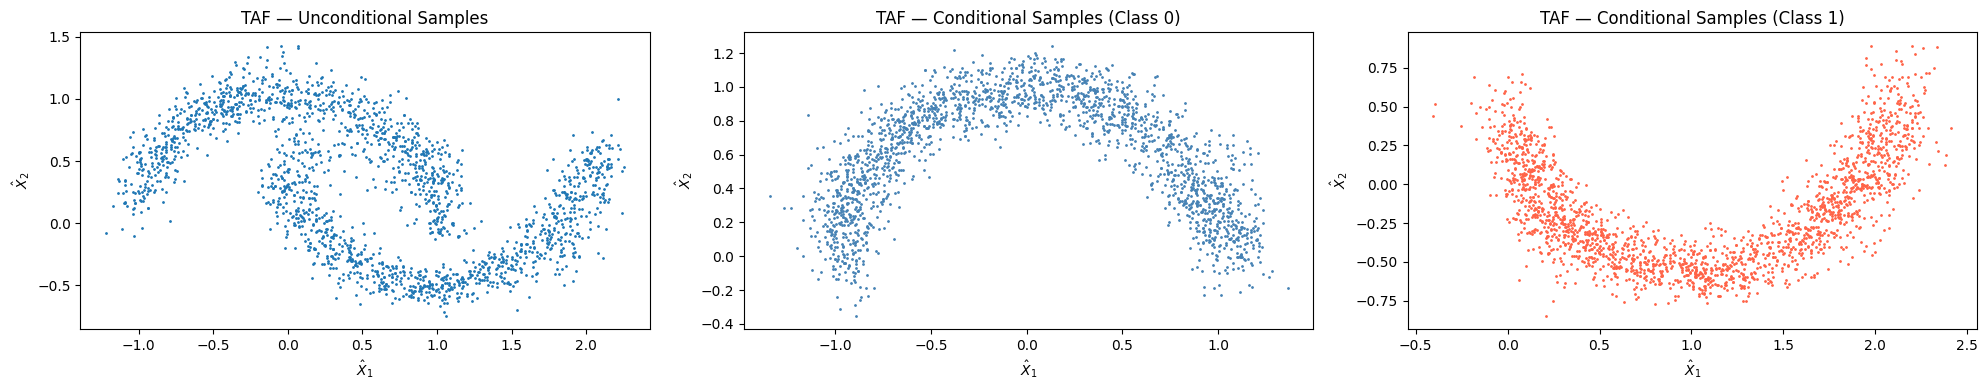

In [45]:
fig, axs = plt.subplots(1, 3, figsize=(20, 4))

axs[0].set_title("TAF — Unconditional Samples")
axs[0].scatter(samples_uncond[:, 0], samples_uncond[:, 1], s=1)
axs[0].set_xlabel(r"$\hat{X}_1$"); axs[0].set_ylabel(r"$\hat{X}_2$")

axs[1].set_title("TAF — Conditional Samples (Class 0)")
axs[1].scatter(samples0[:, 0], samples0[:, 1], s=1, color="steelblue")
axs[1].set_xlabel(r"$\hat{X}_1$"); axs[1].set_ylabel(r"$\hat{X}_2$")

axs[2].set_title("TAF — Conditional Samples (Class 1)")
axs[2].scatter(samples1[:, 0], samples1[:, 1], s=1, color="tomato")
axs[2].set_xlabel(r"$\hat{X}_1$"); axs[2].set_ylabel(r"$\hat{X}_2$")

plt.tight_layout()
plt.show()

## 14. Quantitative Evaluation

Same evaluation harness as the MAF notebook — enabling direct numerical comparison.

- **Test NLL**: negative log-likelihood on a held-out test set (lower = better density estimate)
- **MMD²**: Maximum Mean Discrepancy with RBF kernel between generated and real samples (lower = better sample quality)
- **Sampling speed**: samples per second (higher = faster)

In [46]:
import time
import pandas as pd

def count_params(model):
    return sum(p.numel() for p in model.parameters())

@torch.no_grad()
def eval_nll(model, dataloader, device=None):
    model.eval()
    if device is None:
        device = next(model.parameters()).device
    log_2pi   = math.log(2 * math.pi)
    total_nll = 0.0
    total_n   = 0
    for batch in dataloader:
        x = batch[0].to(device)
        D = x.shape[1]
        y = batch[1].to(device) if getattr(model, "condition_size", None) is not None else None
        z, log_det = model(x, y)
        nll = 0.5 * D * log_2pi + 0.5 * z.pow(2).sum(dim=1) - log_det
        total_nll += nll.sum().item()
        total_n   += x.size(0)
    return total_nll / total_n

def _rbf_kernel(x, y, sigma):
    x_norm = (x**2).sum(dim=1, keepdim=True)
    y_norm = (y**2).sum(dim=1, keepdim=True).t()
    dist2  = x_norm + y_norm - 2.0 * x @ y.t()
    return torch.exp(-dist2 / (2.0 * sigma**2))

@torch.no_grad()
def mmd_rbf(x, y, sigma=None, max_pts=1000):
    x, y = x.detach(), y.detach()
    if sigma is None:
        z    = torch.cat([x, y], dim=0)
        if z.size(0) > max_pts:
            z = z[torch.randperm(z.size(0))[:max_pts]]
        z_norm = (z**2).sum(dim=1, keepdim=True)
        dist2  = z_norm + z_norm.t() - 2.0 * z @ z.t()
        dist2  = dist2[torch.triu(torch.ones_like(dist2), diagonal=1) == 1]
        sigma  = torch.sqrt(torch.median(dist2).clamp(min=1e-12)).item()
    Kxx, Kyy, Kxy = _rbf_kernel(x,x,sigma), _rbf_kernel(y,y,sigma), _rbf_kernel(x,y,sigma)
    n, m = x.size(0), y.size(0)
    Kxx  = Kxx - torch.diag(torch.diag(Kxx)); mmd_xx = Kxx.sum() / (n*(n-1)) if n>1 else 0.
    Kyy  = Kyy - torch.diag(torch.diag(Kyy)); mmd_yy = Kyy.sum() / (m*(m-1)) if m>1 else 0.
    return float((mmd_xx + mmd_yy - 2.0*Kxy.mean()).item())

@torch.no_grad()
def sampling_speed(model, sample_fn, n_samples=2000, n_repeats=20, warmup=5):
    model.eval()
    for _ in range(warmup): sample_fn(n_samples)
    t0 = time.perf_counter()
    for _ in range(n_repeats): sample_fn(n_samples)
    return n_samples * n_repeats / (time.perf_counter() - t0)

In [47]:
# Fixed-seed test sets — use the same seeds as training split for reproducibility
uncond_test_loader, X_test_uncond = get_moons_unconditional(n_samples=5000, seed=99)
cond_test_loader,  X_test_cond, y_test_cond = get_moons_conditional(n_samples=5000, seed=99)

device = next(taf.parameters()).device

def sample_taf_uncond(n): return taf.sample(n)

def sample_ctaf_mix(n):
    n0 = n // 2; n1 = n - n0
    y0_ = torch.zeros(n0, 2, device=device); y0_[:, 0] = 1.0
    y1_ = torch.zeros(n1, 2, device=device); y1_[:, 1] = 1.0
    return torch.cat([ctaf.sample(n0, y=y0_), ctaf.sample(n1, y=y1_)], dim=0)

rows = []

# Unconditional
nll = eval_nll(taf, uncond_test_loader, device=device)
gen = sample_taf_uncond(2000)
mmd = mmd_rbf(gen, X_test_uncond.to(device)[:2000])
sps = sampling_speed(taf, sample_taf_uncond, n_samples=2000)
rows.append({
    "Model":                   "TAF (uncond)",
    "Params":                  count_params(taf),
    "Test NLL ↓":              round(nll, 4),
    "MMD² ↓":                  round(mmd, 6),
    "Sampling (samples/s) ↑":  round(sps, 1),
})

# Conditional (class-balanced mixture)
nll = eval_nll(ctaf, cond_test_loader, device=device)
gen = sample_ctaf_mix(2000)
mmd = mmd_rbf(gen, X_test_cond.to(device)[:2000])
sps = sampling_speed(ctaf, sample_ctaf_mix, n_samples=2000)
rows.append({
    "Model":                   "TAF (cond, mix)",
    "Params":                  count_params(ctaf),
    "Test NLL ↓":              round(nll, 4),
    "MMD² ↓":                  round(mmd, 6),
    "Sampling (samples/s) ↑":  round(sps, 1),
})

taf_df = pd.DataFrame(rows)
taf_df

,Model,Params,Test NLL ↓,MMD² ↓,Sampling (samples/s) ↑
0,TAF (uncond),51592,1.1008,0.002184,44330.9
1,"TAF (cond, mix)",51848,0.4238,0.000564,50664.9


## Ablation Studies

#### Num Layers vs Blocks

In [48]:
taf_1_1 = TAF(
    input_size=2,
    channels=32,      # Transformer hidden width
    num_layers=1,     # Transformer layers per flow block (K)
    head_dim=16,      # per-head attention dimension
    blocks=1,         # number of flow blocks (T ≥ 3 for universality)
)

print(f"TAF unconditional (K=1, B=1) — parameters: {sum(p.numel() for p in taf_1_1.parameters()):,}")

taf_1_2 = TAF(
    input_size=2,
    channels=32,      # Transformer hidden width
    num_layers=1,     # Transformer layers per flow block (K)
    head_dim=16,      # per-head attention dimension
    blocks=2,         # number of flow blocks (T ≥ 3 for universality)
)

print(f"TAF unconditional (K=1, B=2) — parameters: {sum(p.numel() for p in taf_1_2.parameters()):,}")

taf_1_3 = TAF(
    input_size=2,
    channels=32,      # Transformer hidden width
    num_layers=1,     # Transformer layers per flow block (K)
    head_dim=16,      # per-head attention dimension
    blocks=3,         # number of flow blocks (T ≥ 3 for universality)
)

print(f"TAF unconditional (K=1, B=3) — parameters: {sum(p.numel() for p in taf_1_3.parameters()):,}")

taf_1_4 = TAF(
    input_size=2,
    channels=32,      # Transformer hidden width
    num_layers=1,     # Transformer layers per flow block (K)
    head_dim=16,      # per-head attention dimension
    blocks=4,         # number of flow blocks (T ≥ 3 for universality)
)

print(f"TAF unconditional (K=1, B=4) — parameters: {sum(p.numel() for p in taf_1_4.parameters()):,}")

taf_2_1 = TAF(
    input_size=2,
    channels=32,      # Transformer hidden width
    num_layers=2,     # Transformer layers per flow block (K)
    head_dim=16,      # per-head attention dimension
    blocks=1,         # number of flow blocks (T ≥ 3 for universality)
)

print(f"TAF unconditional (K=2, B=1) — parameters: {sum(p.numel() for p in taf_2_1.parameters()):,}")

taf_2_2 = TAF(
    input_size=2,
    channels=32,      # Transformer hidden width
    num_layers=2,     # Transformer layers per flow block (K)
    head_dim=16,      # per-head attention dimension
    blocks=2,         # number of flow blocks (T ≥ 3 for universality)
)

print(f"TAF unconditional (K=2, B=2) — parameters: {sum(p.numel() for p in taf_2_2.parameters()):,}")

taf_2_3 = TAF(
    input_size=2,
    channels=32,      # Transformer hidden width
    num_layers=2,     # Transformer layers per flow block (K)
    head_dim=16,      # per-head attention dimension
    blocks=3,         # number of flow blocks (T ≥ 3 for universality)
)

print(f"TAF unconditional (K=2, B=3) — parameters: {sum(p.numel() for p in taf_2_3.parameters()):,}")

taf_2_4 = TAF(
    input_size=2,
    channels=32,      # Transformer hidden width
    num_layers=2,     # Transformer layers per flow block (K)
    head_dim=16,      # per-head attention dimension
    blocks=4,         # number of flow blocks (T ≥ 3 for universality)
)

print(f"TAF unconditional (K=2, B=4) — parameters: {sum(p.numel() for p in taf_2_4.parameters()):,}")

taf_3_1 = TAF(
    input_size=2,
    channels=32,      # Transformer hidden width
    num_layers=3,     # Transformer layers per flow block (K)
    head_dim=16,      # per-head attention dimension
    blocks=1,         # number of flow blocks (T ≥ 3 for universality)
)

print(f"TAF unconditional (K=3, B=1) — parameters: {sum(p.numel() for p in taf_3_1.parameters()):,}")

taf_3_2 = TAF(
    input_size=2,
    channels=32,      # Transformer hidden width
    num_layers=3,     # Transformer layers per flow block (K)
    head_dim=16,      # per-head attention dimension
    blocks=2,         # number of flow blocks (T ≥ 3 for universality)
)

print(f"TAF unconditional (K=3, B=2) — parameters: {sum(p.numel() for p in taf_3_2.parameters()):,}")

taf_3_3 = TAF(  
    input_size=2,
    channels=32,      # Transformer hidden width
    num_layers=3,     # Transformer layers per flow block (K)
    head_dim=16,      # per-head attention dimension
    blocks=3,         # number of flow blocks (T ≥ 3 for universality)
)

print(f"TAF unconditional (K=3, B=3) — parameters: {sum(p.numel() for p in taf_3_3.parameters()):,}")

taf_3_4 = TAF(
    input_size=2,
    channels=32,      # Transformer hidden width
    num_layers=3,     # Transformer layers per flow block (K)
    head_dim=16,      # per-head attention dimension
    blocks=4,         # number of flow blocks (T ≥ 3 for universality)
)   

print(f"TAF unconditional (K=3, B=4) — parameters: {sum(p.numel() for p in taf_3_4.parameters()):,}")

taf_4_1 = TAF(
    input_size=2,
    channels=32,      # Transformer hidden width
    num_layers=4,     # Transformer layers per flow block (K)
    head_dim=16,      # per-head attention dimension
    blocks=1,         # number of flow blocks (T ≥ 3 for universality)
)

print(f"TAF unconditional (K=4, B=1) — parameters: {sum(p.numel() for p in taf_4_1.parameters()):,}")

taf_4_2 = TAF(
    input_size=2,
    channels=32,      # Transformer hidden width
    num_layers=4,     # Transformer layers per flow block (K)
    head_dim=16,      # per-head attention dimension
    blocks=2,         # number of flow blocks (T ≥ 3 for universality)
)

print(f"TAF unconditional (K=4, B=2) — parameters: {sum(p.numel() for p in taf_4_2.parameters()):,}")

taf_4_3 = TAF(
    input_size=2,
    channels=32,      # Transformer hidden width
    num_layers=4,     # Transformer layers per flow block (K)
    head_dim=16,      # per-head attention dimension
    blocks=3,         # number of flow blocks (T ≥ 3 for universality)
)

print(f"TAF unconditional (K=4, B=3) — parameters: {sum(p.numel() for p in taf_4_3.parameters()):,}")

taf_4_4 = TAF(
    input_size=2,
    channels=32,      # Transformer hidden width
    num_layers=4,     # Transformer layers per flow block (K)
    head_dim=16,      # per-head attention dimension
    blocks=4,         # number of flow blocks (T ≥ 3 for universality)
)
    
print(f"TAF unconditional (K=4, B=4) — parameters: {sum(p.numel() for p in taf_4_4.parameters()):,}")

TAF unconditional (K=1, B=1) — parameters: 12,898
TAF unconditional (K=1, B=2) — parameters: 25,796
TAF unconditional (K=1, B=3) — parameters: 38,694
TAF unconditional (K=1, B=4) — parameters: 51,592
TAF unconditional (K=2, B=1) — parameters: 25,602
TAF unconditional (K=2, B=2) — parameters: 51,204
TAF unconditional (K=2, B=3) — parameters: 76,806
TAF unconditional (K=2, B=4) — parameters: 102,408
TAF unconditional (K=3, B=1) — parameters: 38,306
TAF unconditional (K=3, B=2) — parameters: 76,612
TAF unconditional (K=3, B=3) — parameters: 114,918
TAF unconditional (K=3, B=4) — parameters: 153,224
TAF unconditional (K=4, B=1) — parameters: 51,010
TAF unconditional (K=4, B=2) — parameters: 102,020
TAF unconditional (K=4, B=3) — parameters: 153,030
TAF unconditional (K=4, B=4) — parameters: 204,040


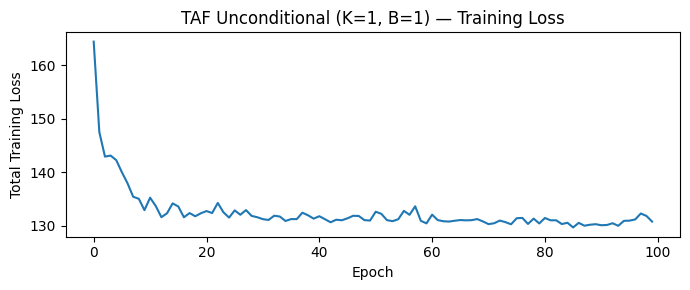

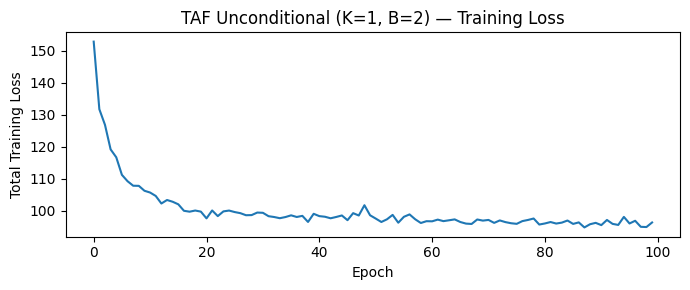

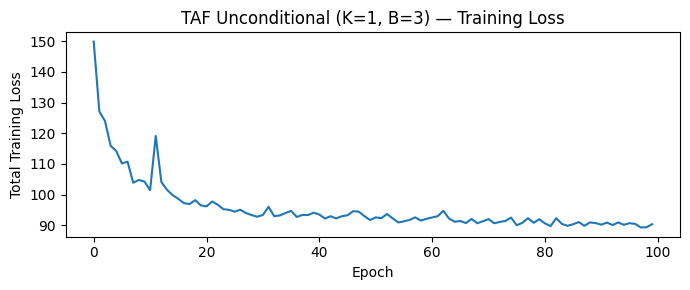

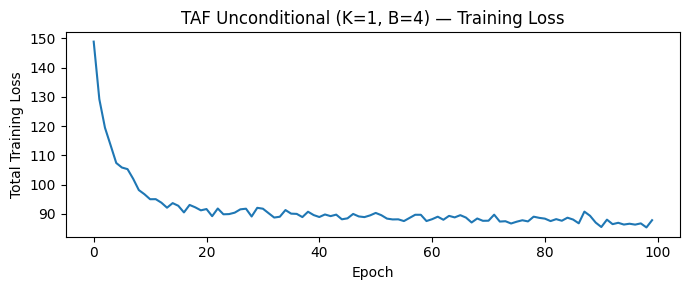

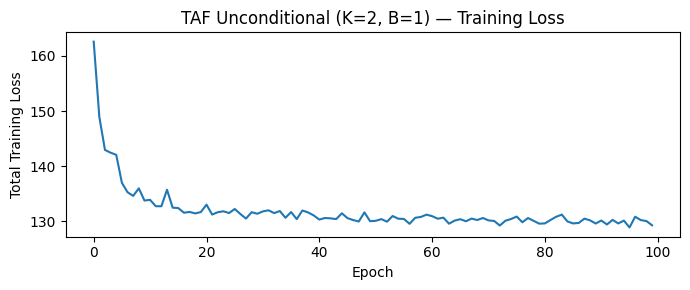

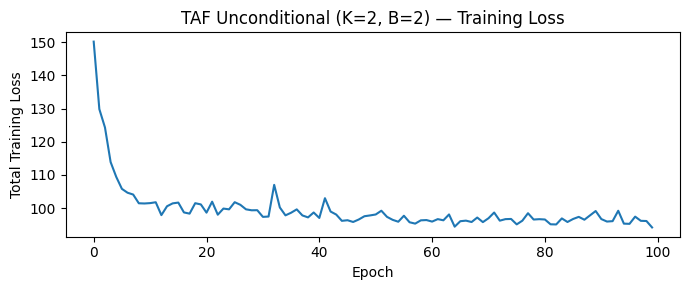

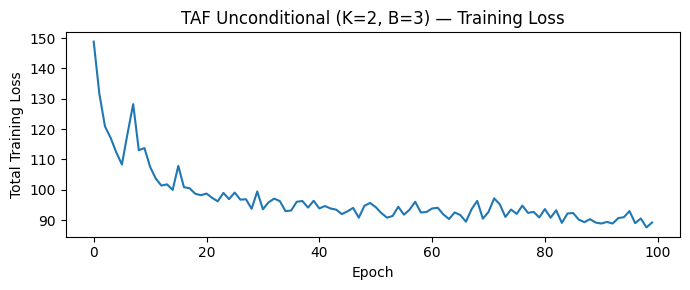

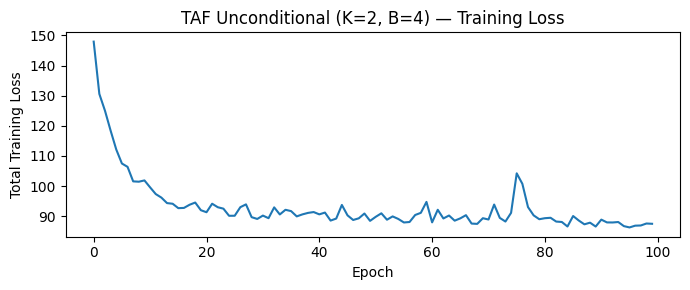

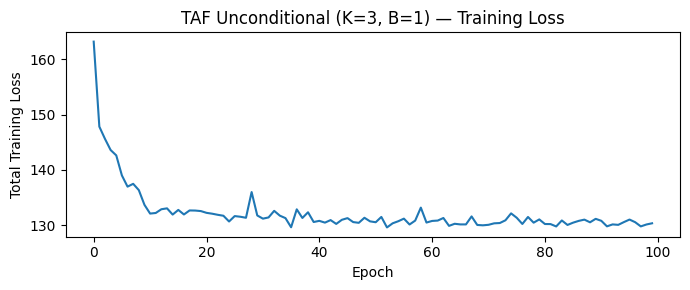

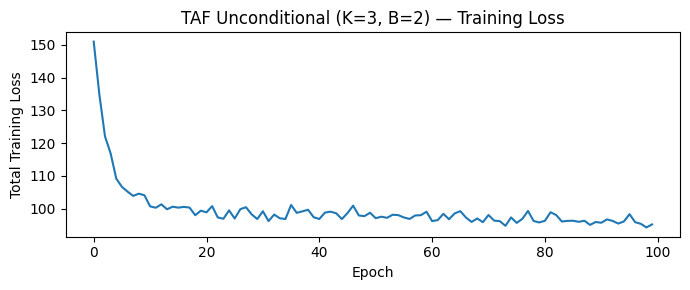

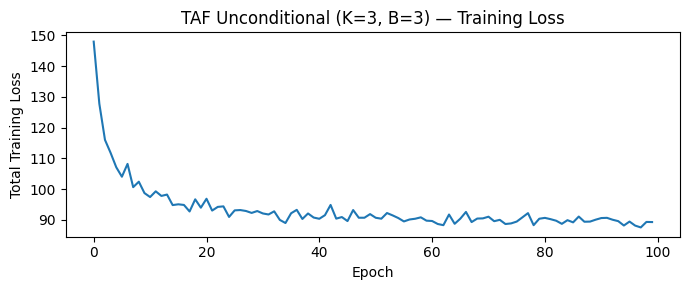

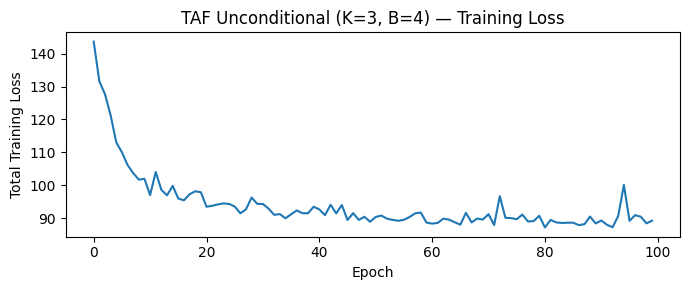

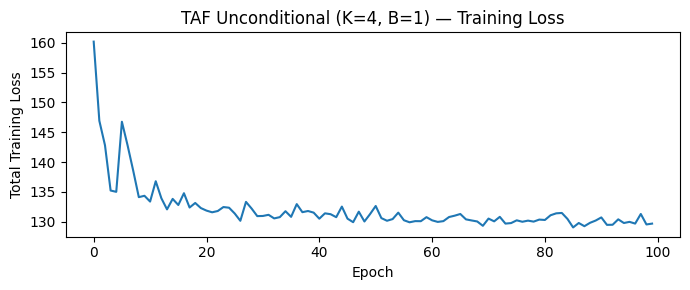

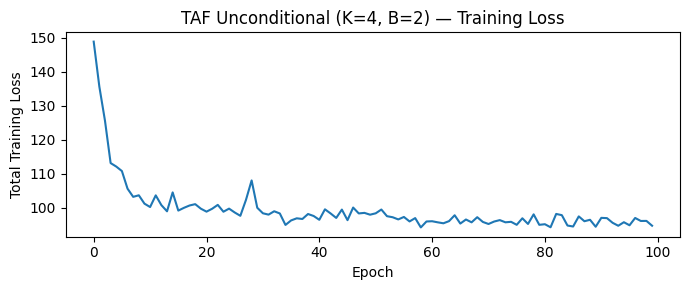

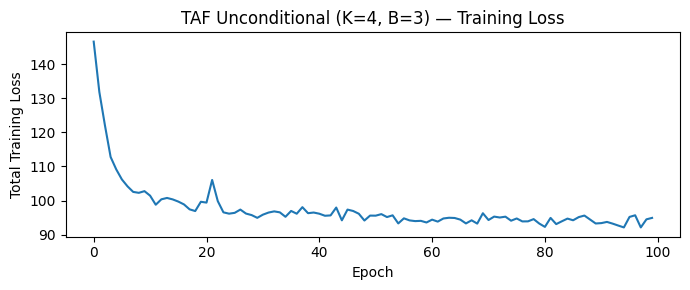

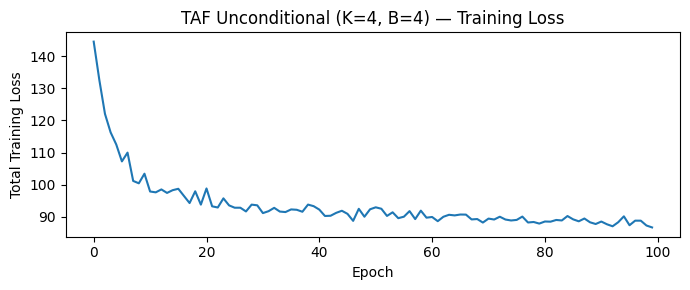

In [49]:
taf_1_1, taf_1_1_losses = train_taf(taf_1_1, uncond_loader, epochs=100, lr=1e-3)
plot_lc(taf_1_1_losses, "TAF Unconditional (K=1, B=1) — Training Loss")
taf_1_1.eval()
samples_uncond_1_1 = taf_1_1.sample(2000).detach().numpy()

taf_1_2, taf_1_2_losses = train_taf(taf_1_2, uncond_loader, epochs=100, lr=1e-3)
plot_lc(taf_1_2_losses, "TAF Unconditional (K=1, B=2) — Training Loss")
taf_1_2.eval()
samples_uncond_1_2 = taf_1_2.sample(2000).detach().numpy()

taf_1_3, taf_1_3_losses = train_taf(taf_1_3, uncond_loader, epochs=100, lr=1e-3)
plot_lc(taf_1_3_losses, "TAF Unconditional (K=1, B=3) — Training Loss")
taf_1_3.eval()  
samples_uncond_1_3 = taf_1_3.sample(2000).detach().numpy()

taf_1_4, taf_1_4_losses = train_taf(taf_1_4, uncond_loader, epochs=100, lr=1e-3)
plot_lc(taf_1_4_losses, "TAF Unconditional (K=1, B=4) — Training Loss")
taf_1_4.eval()  
samples_uncond_1_4 = taf_1_4.sample(2000).detach().numpy()

taf_2_1, taf_2_1_losses = train_taf(taf_2_1, uncond_loader, epochs=100, lr=1e-3)
plot_lc(taf_2_1_losses, "TAF Unconditional (K=2, B=1) — Training Loss")
taf_2_1.eval() 
samples_uncond_2_1 = taf_2_1.sample(2000).detach().numpy()

taf_2_2, taf_2_2_losses = train_taf(taf_2_2, uncond_loader, epochs=100, lr=1e-3)
plot_lc(taf_2_2_losses, "TAF Unconditional (K=2, B=2) — Training Loss")
taf_2_2.eval() 
samples_uncond_2_2 = taf_2_2.sample(2000).detach().numpy()

taf_2_3, taf_2_3_losses = train_taf(taf_2_3, uncond_loader, epochs=100, lr=1e-3)
plot_lc(taf_2_3_losses, "TAF Unconditional (K=2, B=3) — Training Loss")
taf_2_3.eval()
samples_uncond_2_3 = taf_2_3.sample(2000).detach().numpy()

taf_2_4, taf_2_4_losses = train_taf(taf_2_4, uncond_loader, epochs=100, lr=1e-3)
plot_lc(taf_2_4_losses, "TAF Unconditional (K=2, B=4) — Training Loss")
taf_2_4.eval()  
samples_uncond_2_4 = taf_2_4.sample(2000).detach().numpy()

taf_3_1, taf_3_1_losses = train_taf(taf_3_1, uncond_loader, epochs=100, lr=1e-3)
plot_lc(taf_3_1_losses, "TAF Unconditional (K=3, B=1) — Training Loss")
taf_3_1.eval()
samples_uncond_3_1 = taf_3_1.sample(2000).detach().numpy()

taf_3_2, taf_3_2_losses = train_taf(taf_3_2, uncond_loader, epochs=100, lr=1e-3)
plot_lc(taf_3_2_losses, "TAF Unconditional (K=3, B=2) — Training Loss")
taf_3_2.eval()
samples_uncond_3_2 = taf_3_2.sample(2000).detach().numpy()

taf_3_3, taf_3_3_losses = train_taf(taf_3_3, uncond_loader, epochs=100, lr=1e-3)
plot_lc(taf_3_3_losses, "TAF Unconditional (K=3, B=3) — Training Loss")
taf_3_3.eval()
samples_uncond_3_3 = taf_3_3.sample(2000).detach().numpy()              

taf_3_4, taf_3_4_losses = train_taf(taf_3_4, uncond_loader, epochs=100, lr=1e-3)
plot_lc(taf_3_4_losses, "TAF Unconditional (K=3, B=4) — Training Loss")
taf_3_4.eval()
samples_uncond_3_4 = taf_3_4.sample(2000).detach().numpy()

taf_4_1, taf_4_1_losses = train_taf(taf_4_1, uncond_loader, epochs=100, lr=1e-3)
plot_lc(taf_4_1_losses, "TAF Unconditional (K=4, B=1) — Training Loss")
taf_4_1.eval() 
samples_uncond_4_1 = taf_4_1.sample(2000).detach().numpy()

taf_4_2, taf_4_2_losses = train_taf(taf_4_2, uncond_loader, epochs=100, lr=1e-3)
plot_lc(taf_4_2_losses, "TAF Unconditional (K=4, B=2) — Training Loss")
taf_4_2.eval()
samples_uncond_4_2 = taf_4_2.sample(2000).detach().numpy()

taf_4_3, taf_4_3_losses = train_taf(taf_4_3, uncond_loader, epochs=100, lr=1e-3)
plot_lc(taf_4_3_losses, "TAF Unconditional (K=4, B=3) — Training Loss")
taf_4_3.eval()
samples_uncond_4_3 = taf_4_3.sample(2000).detach().numpy()

taf_4_4, taf_4_4_losses = train_taf(taf_4_4, uncond_loader, epochs=100, lr=1e-3)
plot_lc(taf_4_4_losses, "TAF Unconditional (K=4, B=4) — Training Loss")
taf_4_4.eval()
samples_uncond_4_4 = taf_4_4.sample(2000).detach().numpy()

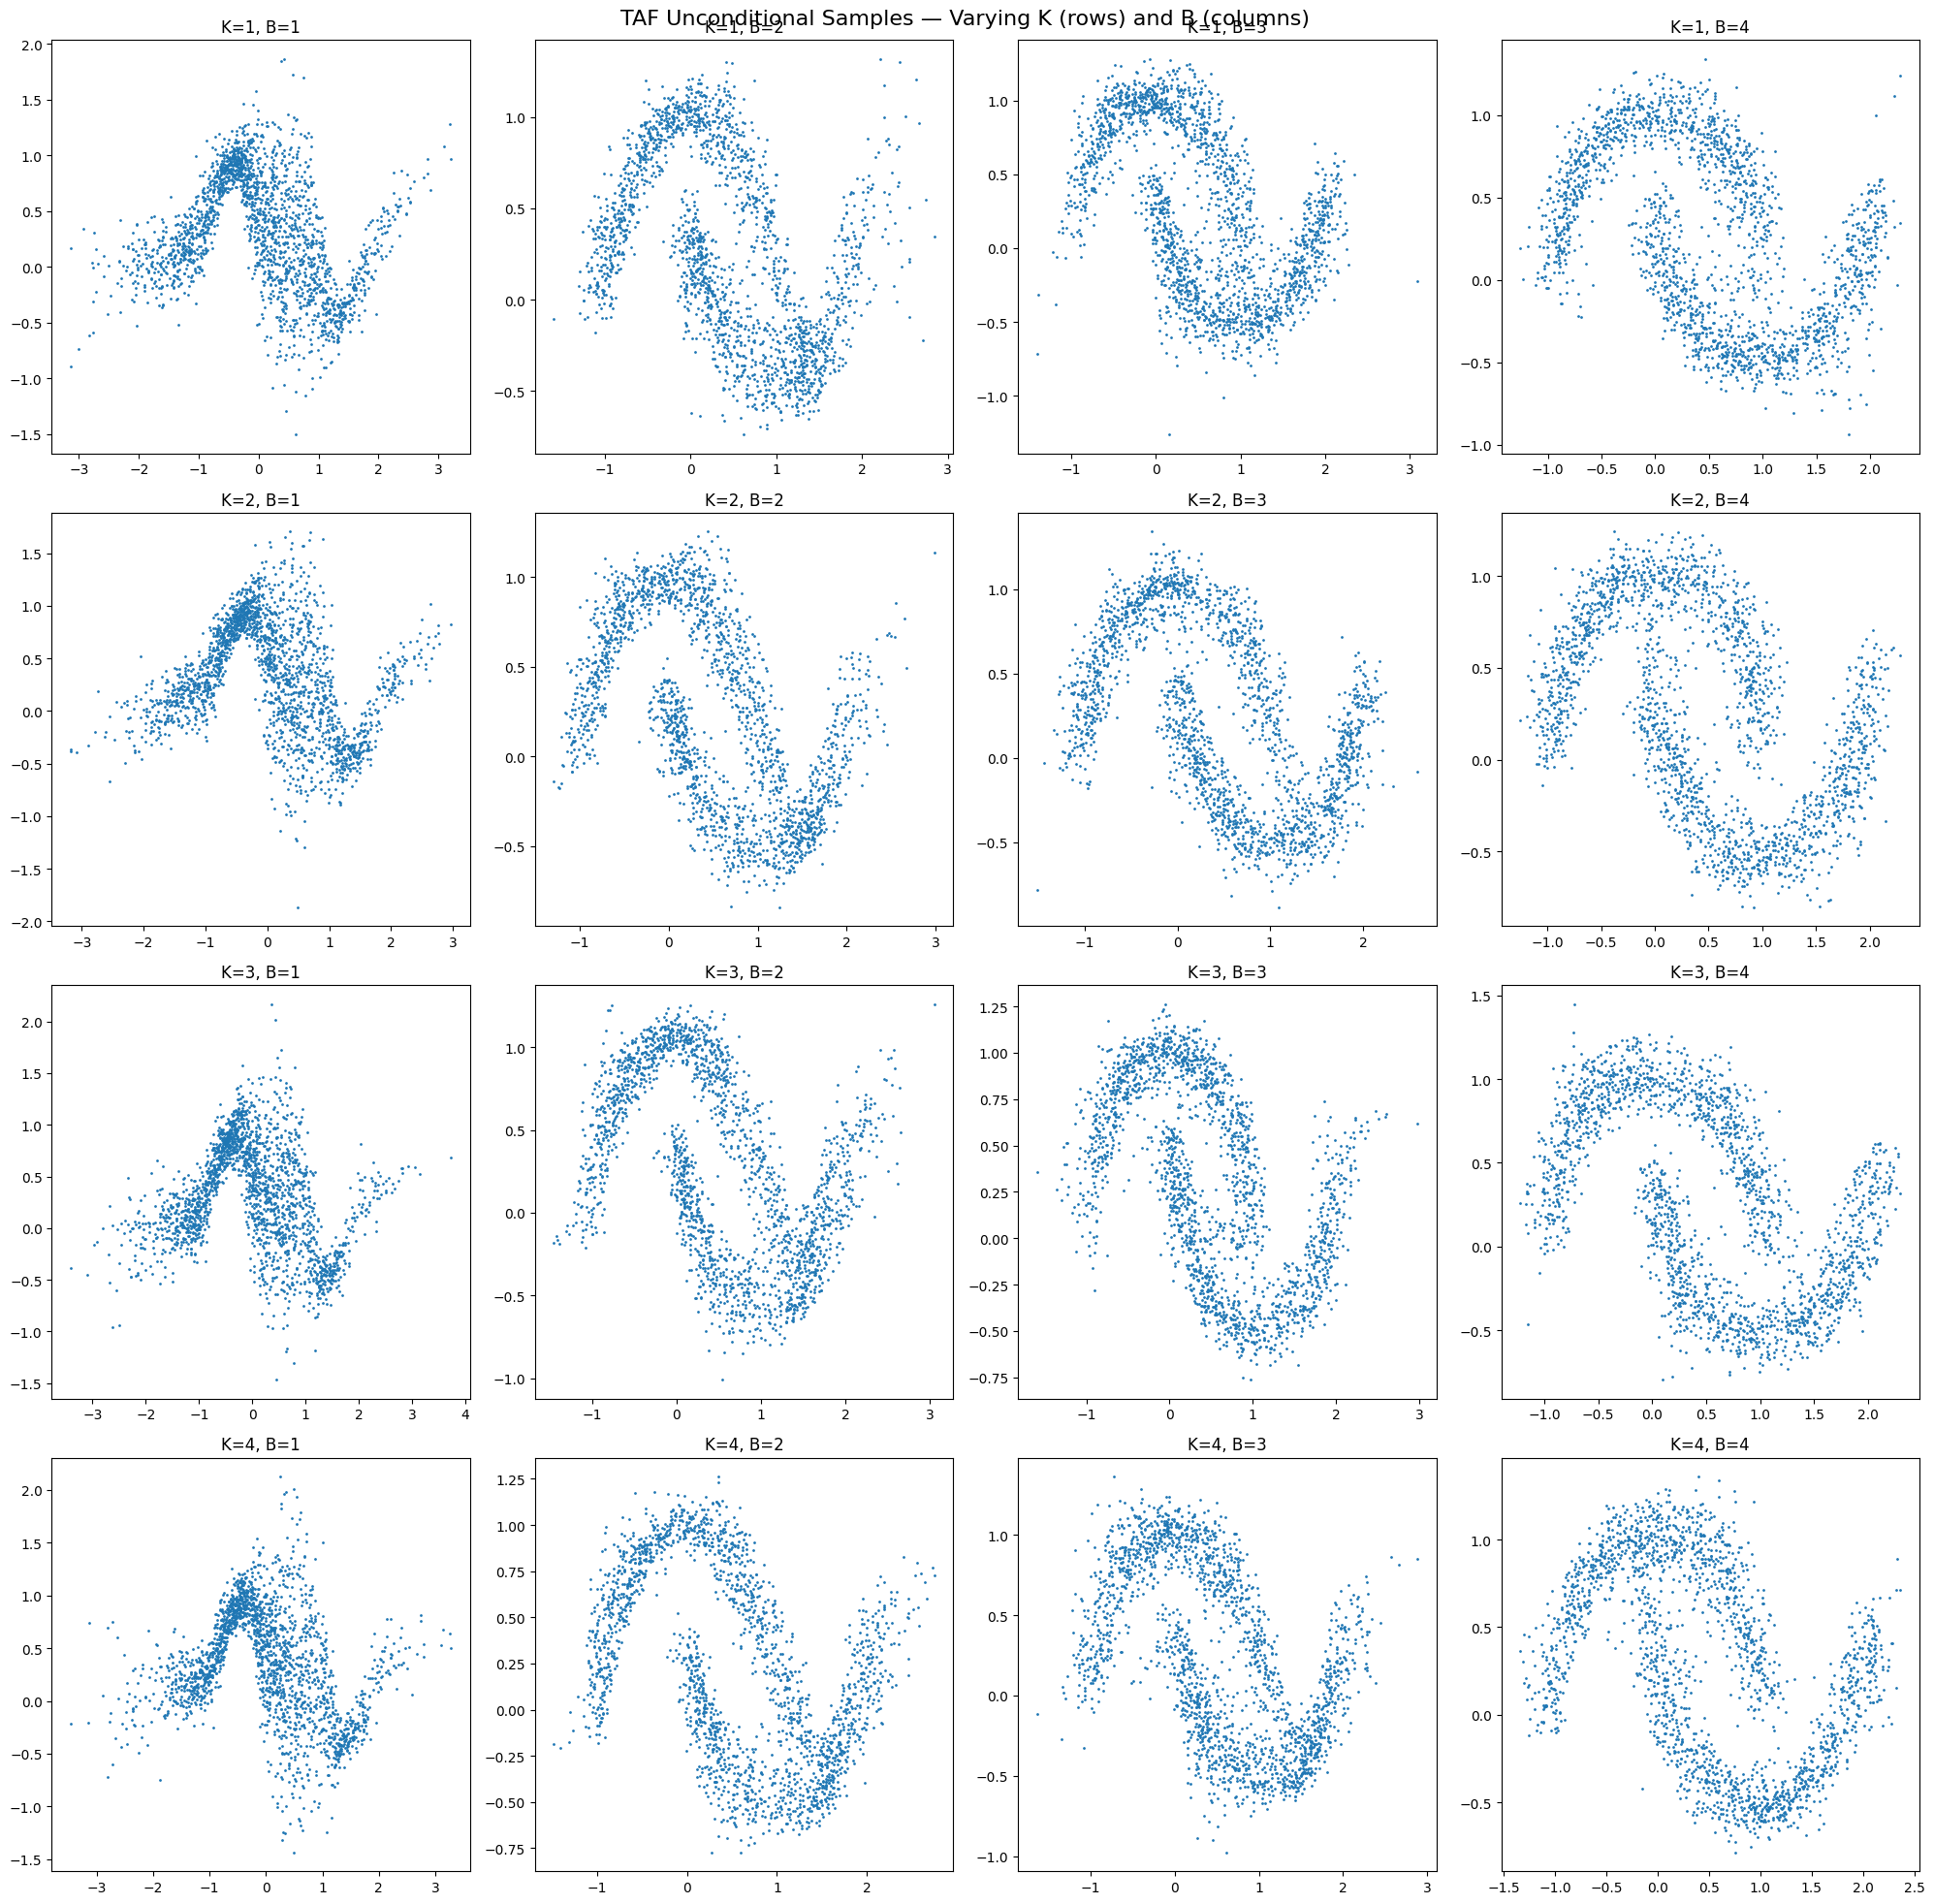

In [50]:
fig, axs = plt.subplots(4, 4, figsize=(20, 20))
plt.suptitle("TAF Unconditional Samples — Varying K (rows) and B (columns)", fontsize=16)

axs[0,0].set_title("K=1, B=1")
axs[0,0].scatter(samples_uncond_1_1[:, 0], samples_uncond_1_1[:, 1], s=1)

axs[0,1].set_title("K=1, B=2")
axs[0,1].scatter(samples_uncond_1_2[:, 0], samples_uncond_1_2[:, 1], s=1)

axs[0,2].set_title("K=1, B=3")
axs[0,2].scatter(samples_uncond_1_3[:, 0], samples_uncond_1_3[:, 1], s=1)

axs[0,3].set_title("K=1, B=4")
axs[0,3].scatter(samples_uncond_1_4[:, 0], samples_uncond_1_4[:, 1], s=1)

axs[1,0].set_title("K=2, B=1")
axs[1,0].scatter(samples_uncond_2_1[:, 0], samples_uncond_2_1[:, 1], s=1)

axs[1,1].set_title("K=2, B=2")
axs[1,1].scatter(samples_uncond_2_2[:, 0], samples_uncond_2_2[:, 1], s=1)   

axs[1,2].set_title("K=2, B=3")
axs[1,2].scatter(samples_uncond_2_3[:, 0], samples_uncond_2_3[:, 1], s=1)

axs[1,3].set_title("K=2, B=4")
axs[1,3].scatter(samples_uncond_2_4[:, 0], samples_uncond_2_4[:, 1], s=1)

axs[2,0].set_title("K=3, B=1")
axs[2,0].scatter(samples_uncond_3_1[:, 0], samples_uncond_3_1[:, 1], s=1)

axs[2,1].set_title("K=3, B=2")
axs[2,1].scatter(samples_uncond_3_2[:, 0], samples_uncond_3_2[:, 1], s=1)

axs[2,2].set_title("K=3, B=3")
axs[2,2].scatter(samples_uncond_3_3[:, 0], samples_uncond_3_3[:, 1], s=1)

axs[2,3].set_title("K=3, B=4")
axs[2,3].scatter(samples_uncond_3_4[:, 0], samples_uncond_3_4[:, 1], s=1)

axs[3,0].set_title("K=4, B=1")
axs[3,0].scatter(samples_uncond_4_1[:, 0], samples_uncond_4_1[:, 1], s=1)

axs[3,1].set_title("K=4, B=2")
axs[3,1].scatter(samples_uncond_4_2[:, 0], samples_uncond_4_2[:, 1], s=1)

axs[3,2].set_title("K=4, B=3")
axs[3,2].scatter(samples_uncond_4_3[:, 0], samples_uncond_4_3[:, 1], s=1)

axs[3,3].set_title("K=4, B=4")
axs[3,3].scatter(samples_uncond_4_4[:, 0], samples_uncond_4_4[:, 1], s=1)

plt.tight_layout()
plt.show()

In [51]:
import numpy as np

models = [
    (1,1,taf_1_1),
    (1,2,taf_1_2),
    (1,3,taf_1_3),
    (1,4,taf_1_4),
    (2,1,taf_2_1),
    (2,2,taf_2_2),
    (2,3,taf_2_3),
    (2,4,taf_2_4),
    (3,1,taf_3_1),
    (3,2,taf_3_2),
    (3,3,taf_3_3),
    (3,4,taf_3_4),
    (4,1,taf_4_1),
    (4,2,taf_4_2),
    (4,3,taf_4_3),
    (4,4,taf_4_4),
]

nll_grid = np.zeros((4,4))
mmd_grid = np.zeros((4,4))
sps_grid = np.zeros((4,4))

for k, b, model in models:
    nll = eval_nll(model, uncond_test_loader, device=device)
    gen = model.sample(2000)
    mmd = mmd_rbf(gen, X_test_uncond.to(device)[:2000])
    sps = sampling_speed(model, lambda n: model.sample(n), n_samples=2000)
    nll_grid[k-1, b-1] = nll
    mmd_grid[k-1, b-1] = mmd
    sps_grid[k-1, b-1] = sps

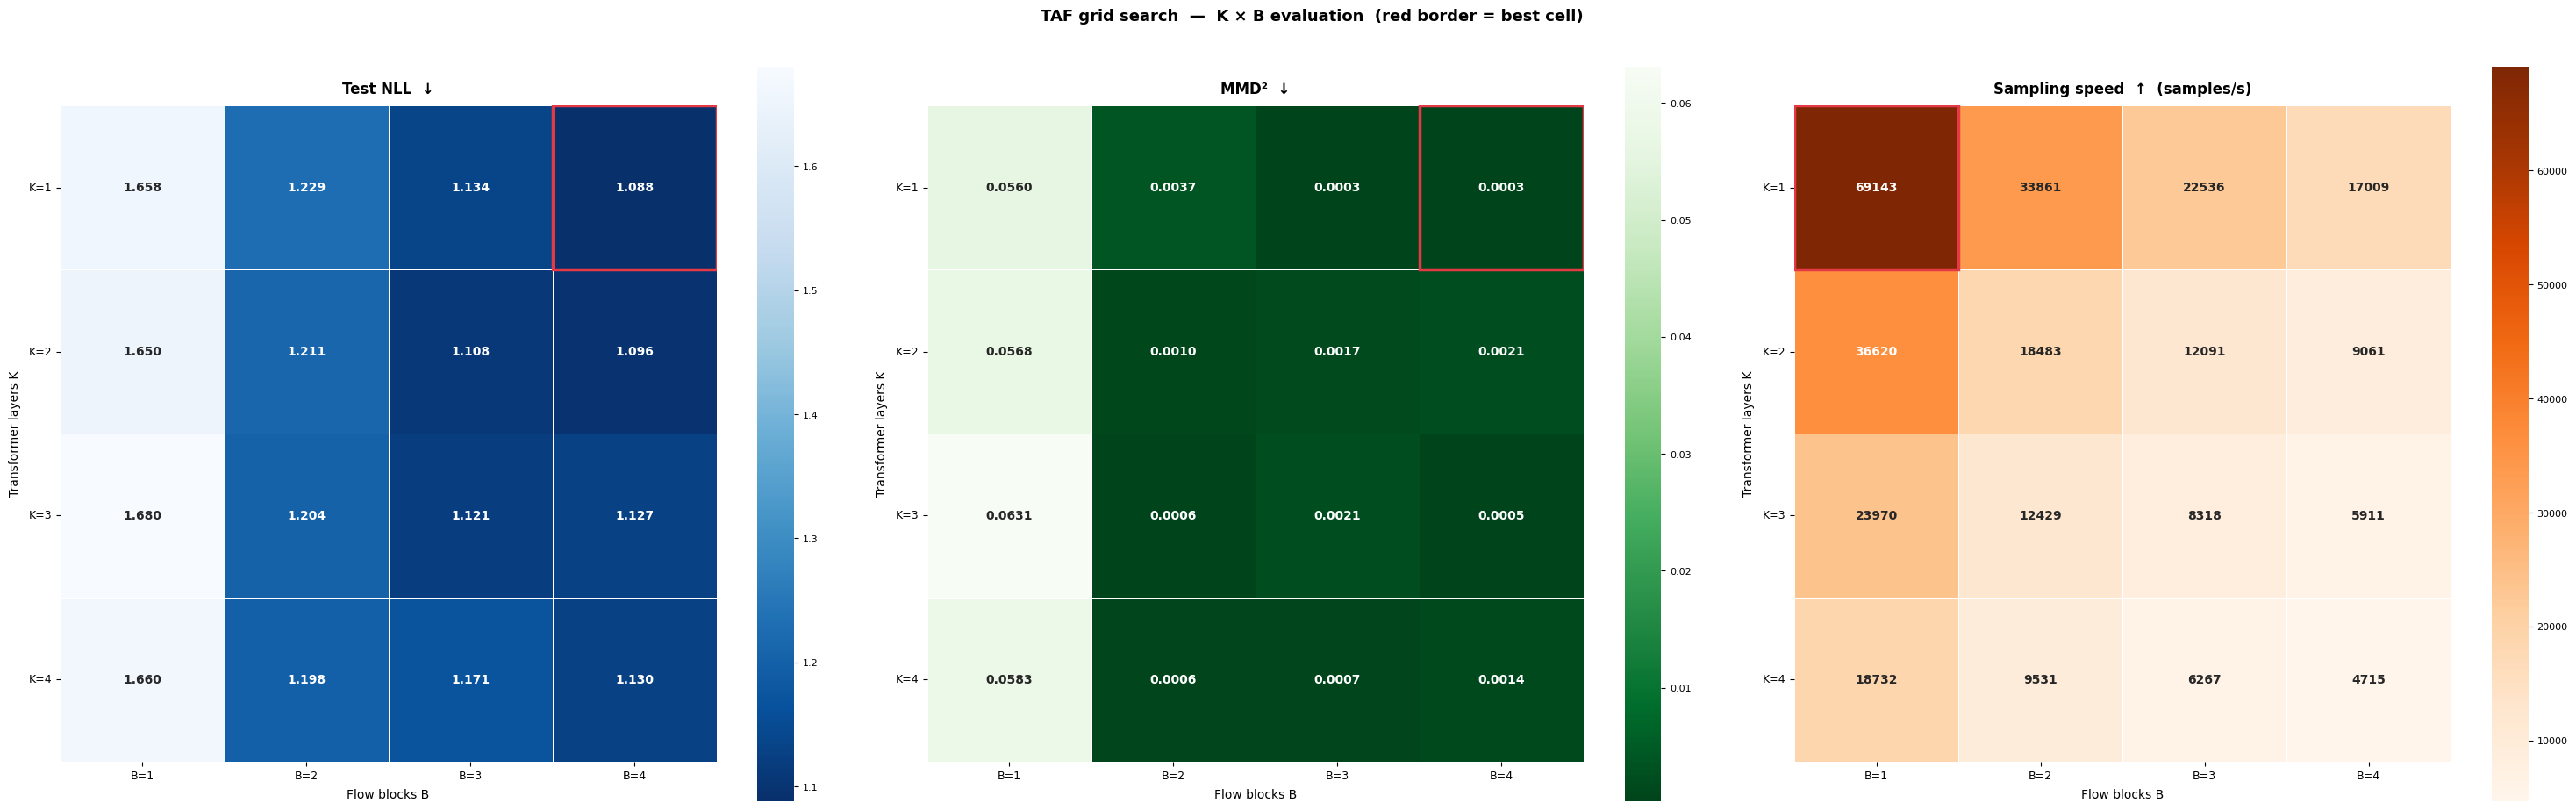

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

row_labels = [f"K={k}" for k in range(1, 5)]     # rows = transformer layers K
col_labels = [f"B={b}" for b in range(1, 5)]     # cols = flow blocks B

metrics = [
    {"grid": nll_grid, "title": "Test NLL  ↓",
     "cmap": "Blues_r",  "better": "lower",  "decimals": 3},
    {"grid": mmd_grid, "title": "MMD²  ↓",
     "cmap": "Greens_r", "better": "lower",  "decimals": 4},
    {"grid": sps_grid, "title": "Sampling speed  ↑  (samples/s)",
     "cmap": "Oranges",  "better": "higher", "decimals": 0},
]

fig, axes = plt.subplots(1, 3, figsize=(30, 9))
fig.subplots_adjust(wspace=0.45)

for ax, m in zip(axes, metrics):
    g    = m["grid"]
    best = np.unravel_index(
        np.argmin(g) if m["better"] == "lower" else np.argmax(g), g.shape
    )
    d     = m["decimals"]
    annot = np.array([[f"{v:.{d}f}" for v in row] for row in g])

    sns.heatmap(g, ax=ax, cmap=m["cmap"], annot=annot, fmt="",
                annot_kws={"size": 10, "weight": "bold"},
                linewidths=0.5, linecolor="white", cbar=True,
                xticklabels=col_labels, yticklabels=row_labels, square=True)

    ax.add_patch(plt.Rectangle(
        (best[1], best[0]), 1, 1,
        fill=False, edgecolor="#e63946", linewidth=2.5, zorder=5
    ))
    ax.set_title(m["title"], fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel("Flow blocks B", fontsize=10, labelpad=6)
    ax.set_ylabel("Transformer layers K", fontsize=10, labelpad=6)
    ax.tick_params(axis="both", labelsize=9)
    ax.yaxis.set_tick_params(rotation=0)
    ax.collections[0].colorbar.ax.tick_params(labelsize=8)

fig.suptitle("TAF grid search  —  K × B evaluation  (red border = best cell)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()